D:\GithubProject\MADRL_ESS\REMAKE\utils\records.py:378: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles=[], labels=[], loc="upper right")


,controller,soc_mode,storage_charge_cost_total_eur,storage_discharge_revenue_total_eur,storage_profit_total_eur,storage_objective_total_eur,system_other_cost_eur,total_eur,soc_penalty_total,voltage_penalty_total,...,voltage_step_delta_p95_pu,voltage_step_delta_max_pu,voltage_spread_mean_pu,voltage_spread_max_pu,trafo_overload_steps,trafo_loading_max_pct,feeder_netload_ramp_mean_abs_kw,feeder_netload_ramp_max_kw,battery_net_power_kw_mean_abs,returned_primary_objective_eur
0,Global MISOCP,continuous,72.025172,95.880064,23.854891,-23.854891,0.0,-23.854896,0.000390,0.000049,...,0.014672,0.030993,0.005861,0.018830,10,131.906784,32.477897,141.137840,45.059213,-23.854896
1,Local MPC + Perfect Forecast,continuous,68.251069,105.191919,36.940850,-36.940850,0.0,-36.940851,0.300462,0.000000,...,0.015935,0.041291,0.006053,0.017652,9,150.452530,34.016655,171.504536,45.335423,-36.940851
2,Local MPC + LSTM Forecast,continuous,65.924157,90.564667,24.640510,-24.640510,0.0,-24.640509,0.418630,0.000043,...,0.017010,0.033036,0.006086,0.023114,11,150.452530,36.064104,163.248703,40.365545,-24.640509
3,ADMM MPC + LSTM Forecast,continuous,70.466563,96.405264,25.938701,-25.938701,0.0,-25.938701,0.000399,0.000008,...,0.014072,0.021481,0.005968,0.018830,12,153.964569,33.465416,118.895237,45.059213,-25.938701
4,MADRL + No Safety + LSTM Forecast,continuous,100.709896,80.578593,-20.131303,20.131303,0.0,20.131305,1.624583,0.000000,...,0.015639,0.030119,0.006503,0.022093,2,128.658081,34.250710,156.381836,47.544250,20.131305
5,MADRL + Safety Penalty + LSTM Forecast,continuous,100.709896,80.578593,-20.131303,20.131303,0.0,20.131305,1.624583,0.000000,...,0.015639,0.030119,0.006503,0.022093,2,128.658081,34.250710,156.381836,47.544250,20.131305
6,MADRL + Safety Projection + LSTM Forecast,continuous,100.421971,80.444837,-19.977133,19.977133,0.0,19.977136,1.780770,0.000000,...,0.014793,0.030119,0.006518,0.022093,2,113.149307,33.450490,130.946716,47.477910,19.977136


,controller,storage_discharge_revenue_total_eur,storage_charge_cost_total_eur,storage_profit_total_eur
0,Global MISOCP,95.880064,72.025172,23.854891
1,Local MPC + Perfect Forecast,105.191919,68.251069,36.940850
2,Local MPC + LSTM Forecast,90.564667,65.924157,24.640510
3,ADMM MPC + LSTM Forecast,96.405264,70.466563,25.938701
4,MADRL + No Safety + LSTM Forecast,80.578593,100.709896,-20.131303
5,MADRL + Safety Penalty + LSTM Forecast,80.578593,100.709896,-20.131303
6,MADRL + Safety Projection + LSTM Forecast,80.444837,100.421971,-19.977133


,controller,voltage_violation_steps,voltage_violation_bus_points,voltage_step_delta_p95_pu,voltage_step_delta_max_pu,voltage_spread_mean_pu,voltage_spread_max_pu,trafo_overload_steps,trafo_loading_max_pct,feeder_netload_ramp_mean_abs_kw,feeder_netload_ramp_max_kw
0,Global MISOCP,3,3,0.014672,0.030993,0.005861,0.018830,10,131.906784,32.477897,141.137840
1,Local MPC + Perfect Forecast,0,0,0.015935,0.041291,0.006053,0.017652,9,150.452530,34.016655,171.504536
2,Local MPC + LSTM Forecast,1,1,0.017010,0.033036,0.006086,0.023114,11,150.452530,36.064104,163.248703
3,ADMM MPC + LSTM Forecast,2,2,0.014072,0.021481,0.005968,0.018830,12,153.964569,33.465416,118.895237
4,MADRL + No Safety + LSTM Forecast,0,0,0.015639,0.030119,0.006503,0.022093,2,128.658081,34.250710,156.381836
5,MADRL + Safety Penalty + LSTM Forecast,0,0,0.015639,0.030119,0.006503,0.022093,2,128.658081,34.250710,156.381836
6,MADRL + Safety Projection + LSTM Forecast,0,0,0.014793,0.030119,0.006518,0.022093,2,113.149307,33.450490,130.946716


1. 电价


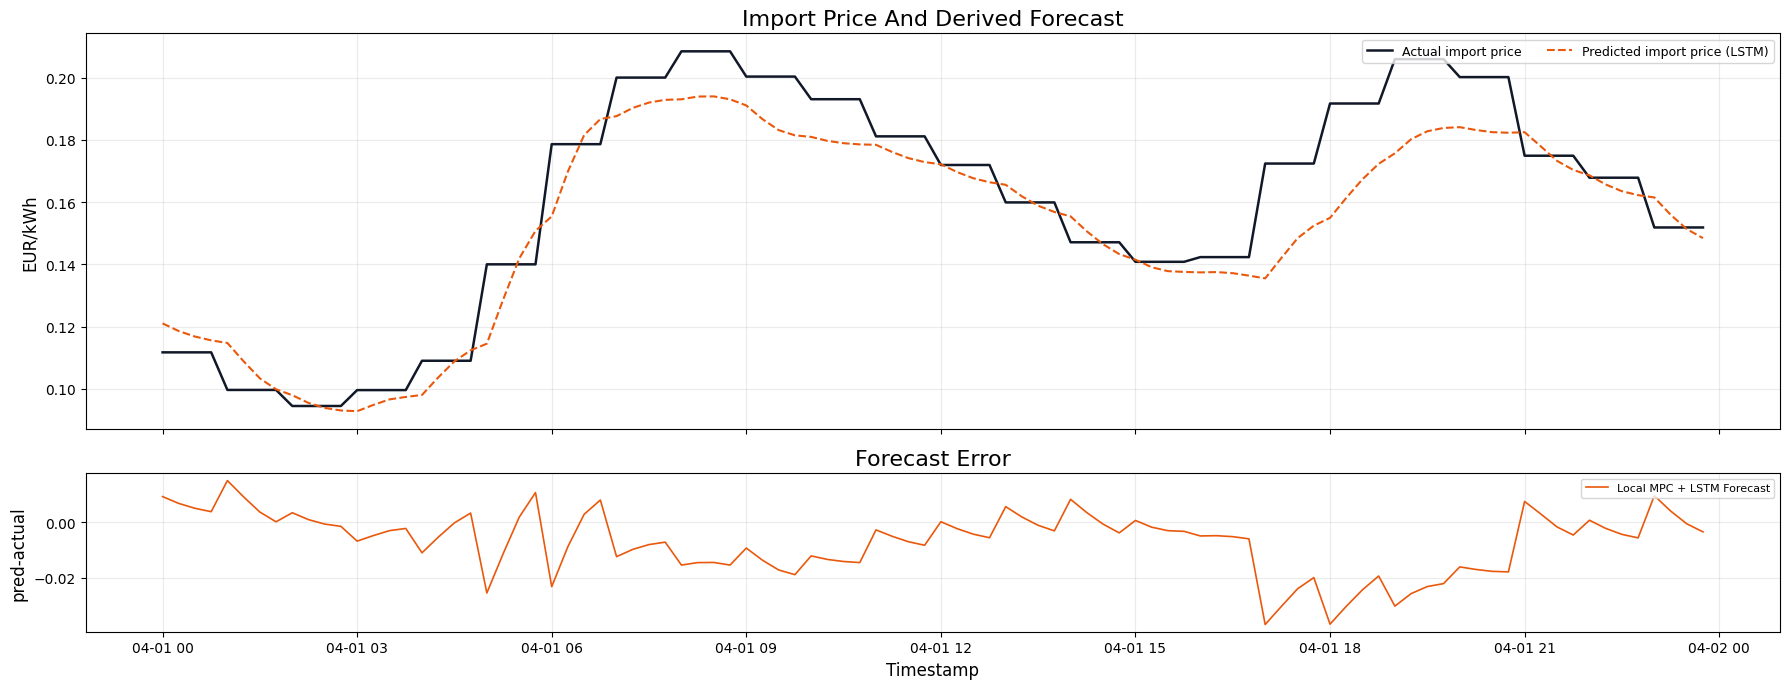

2. 电压


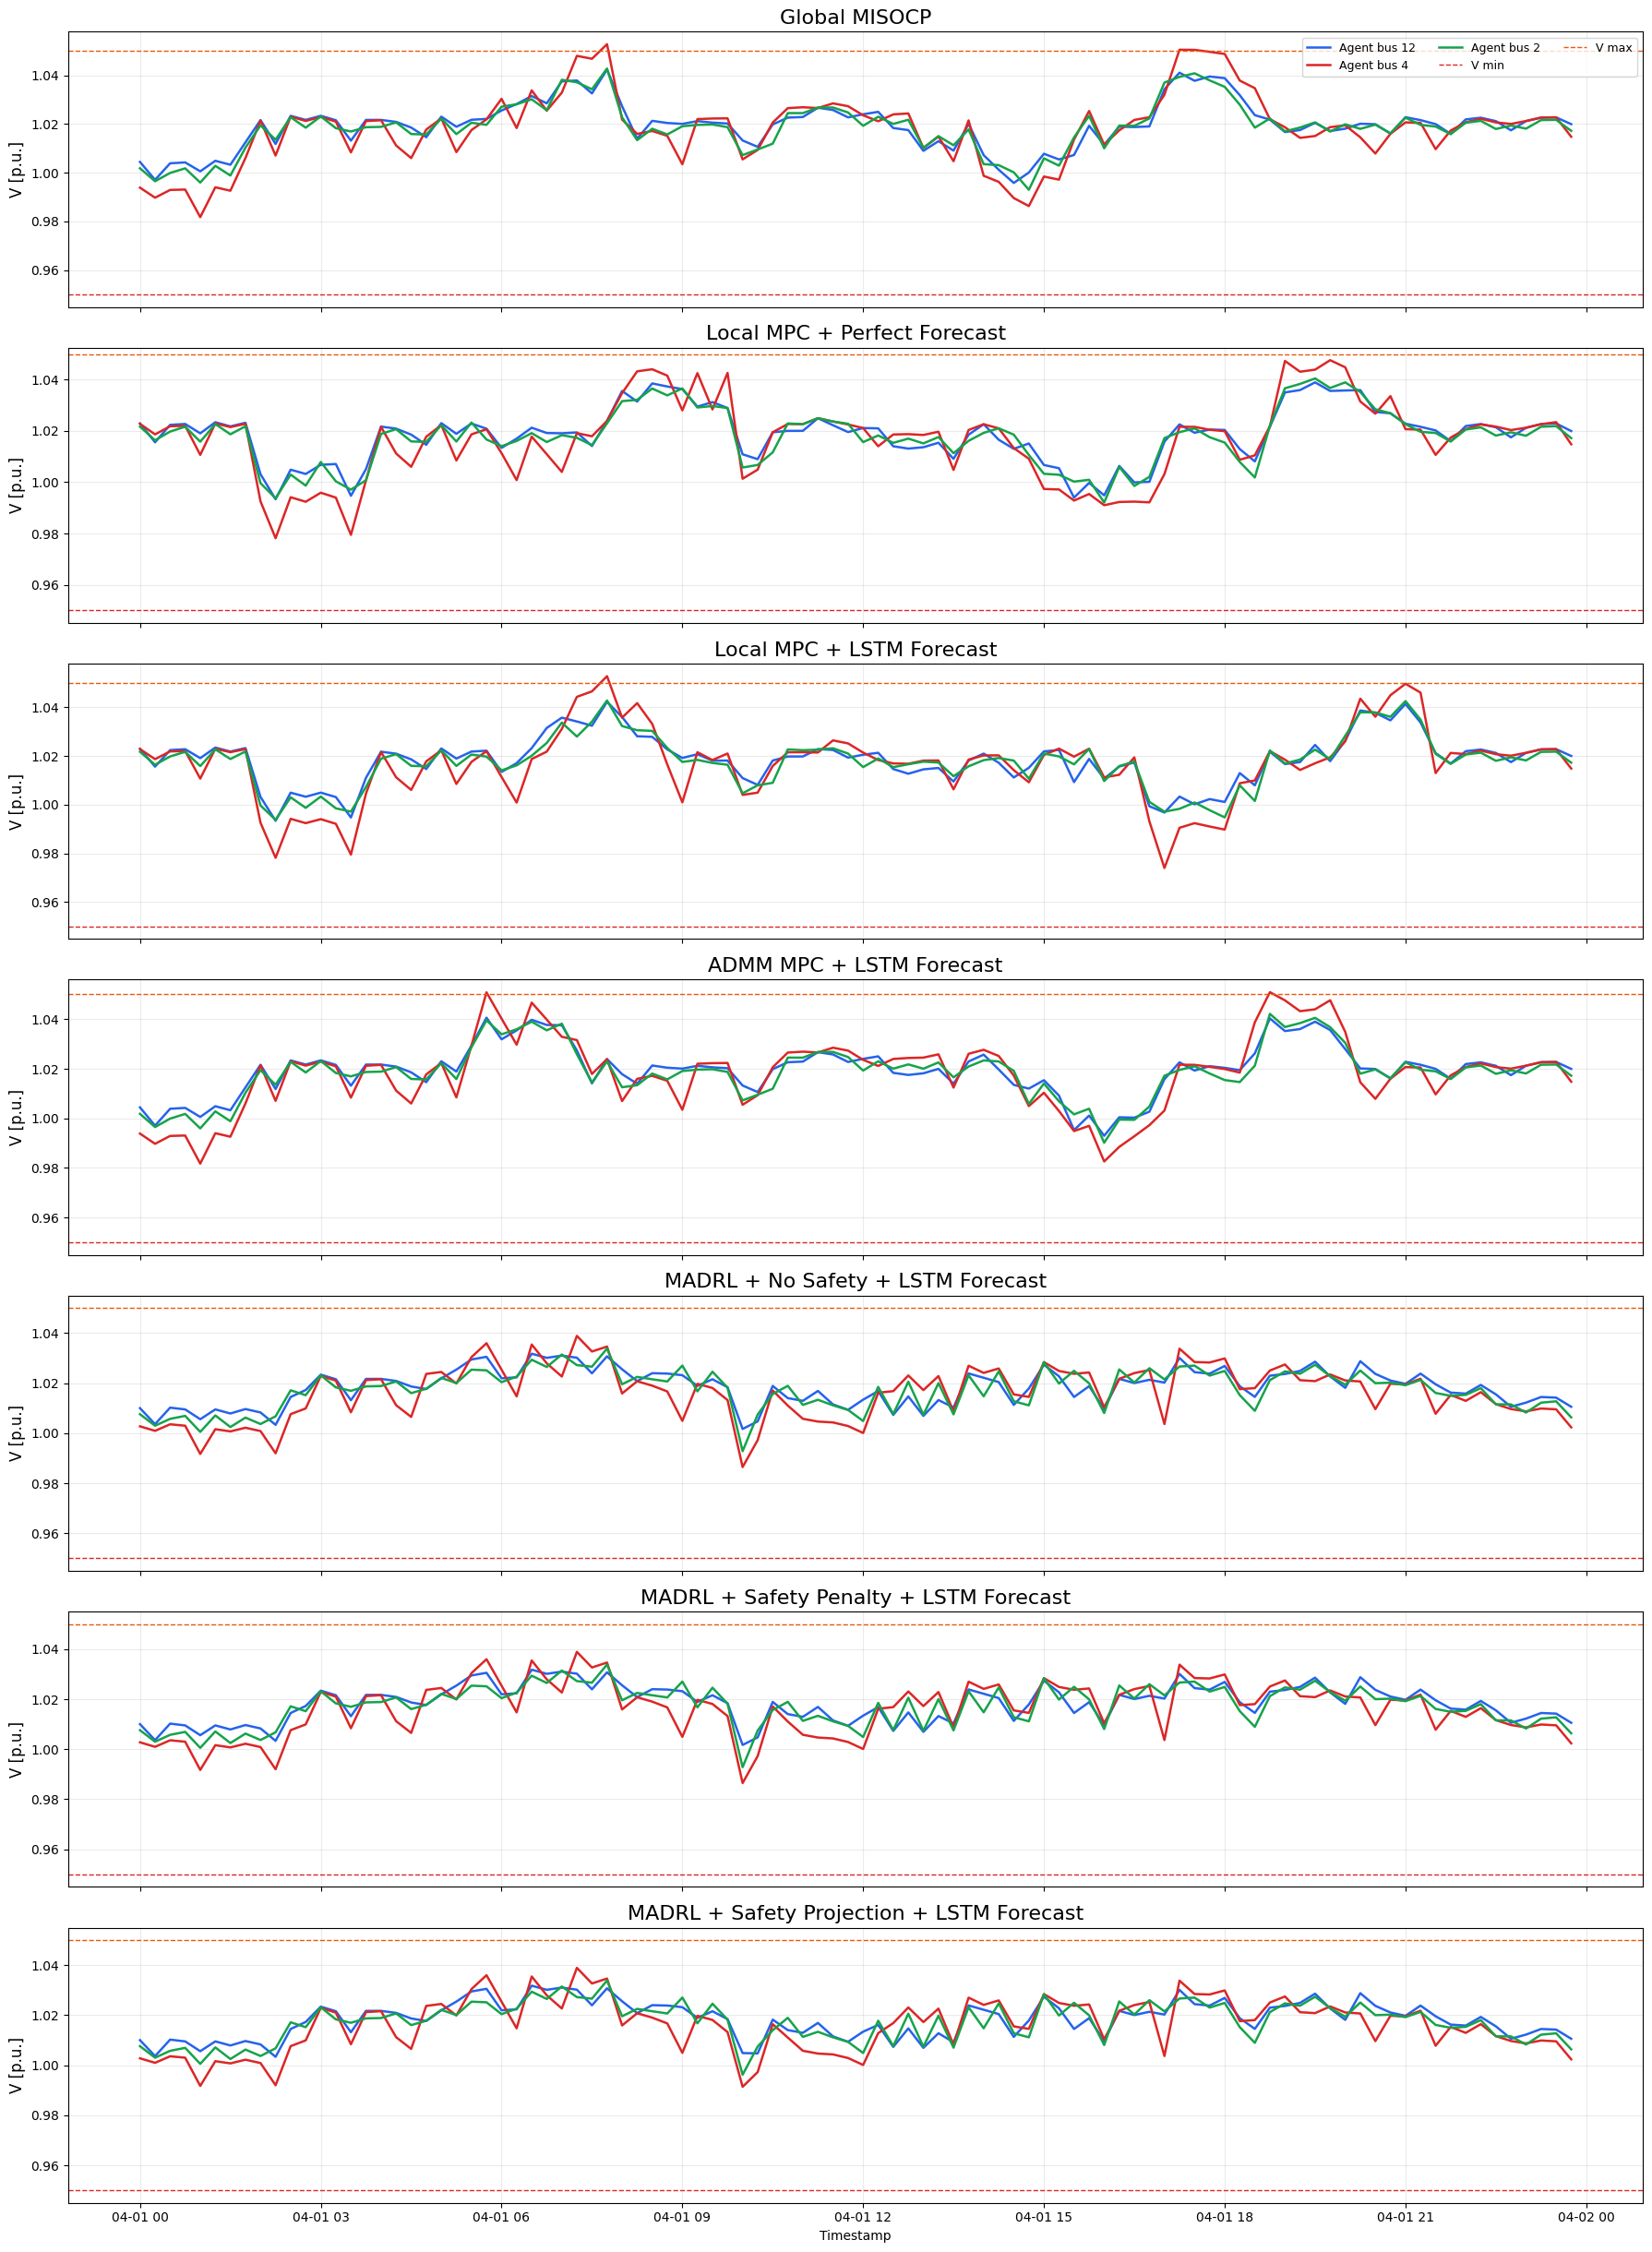

3. 净负荷


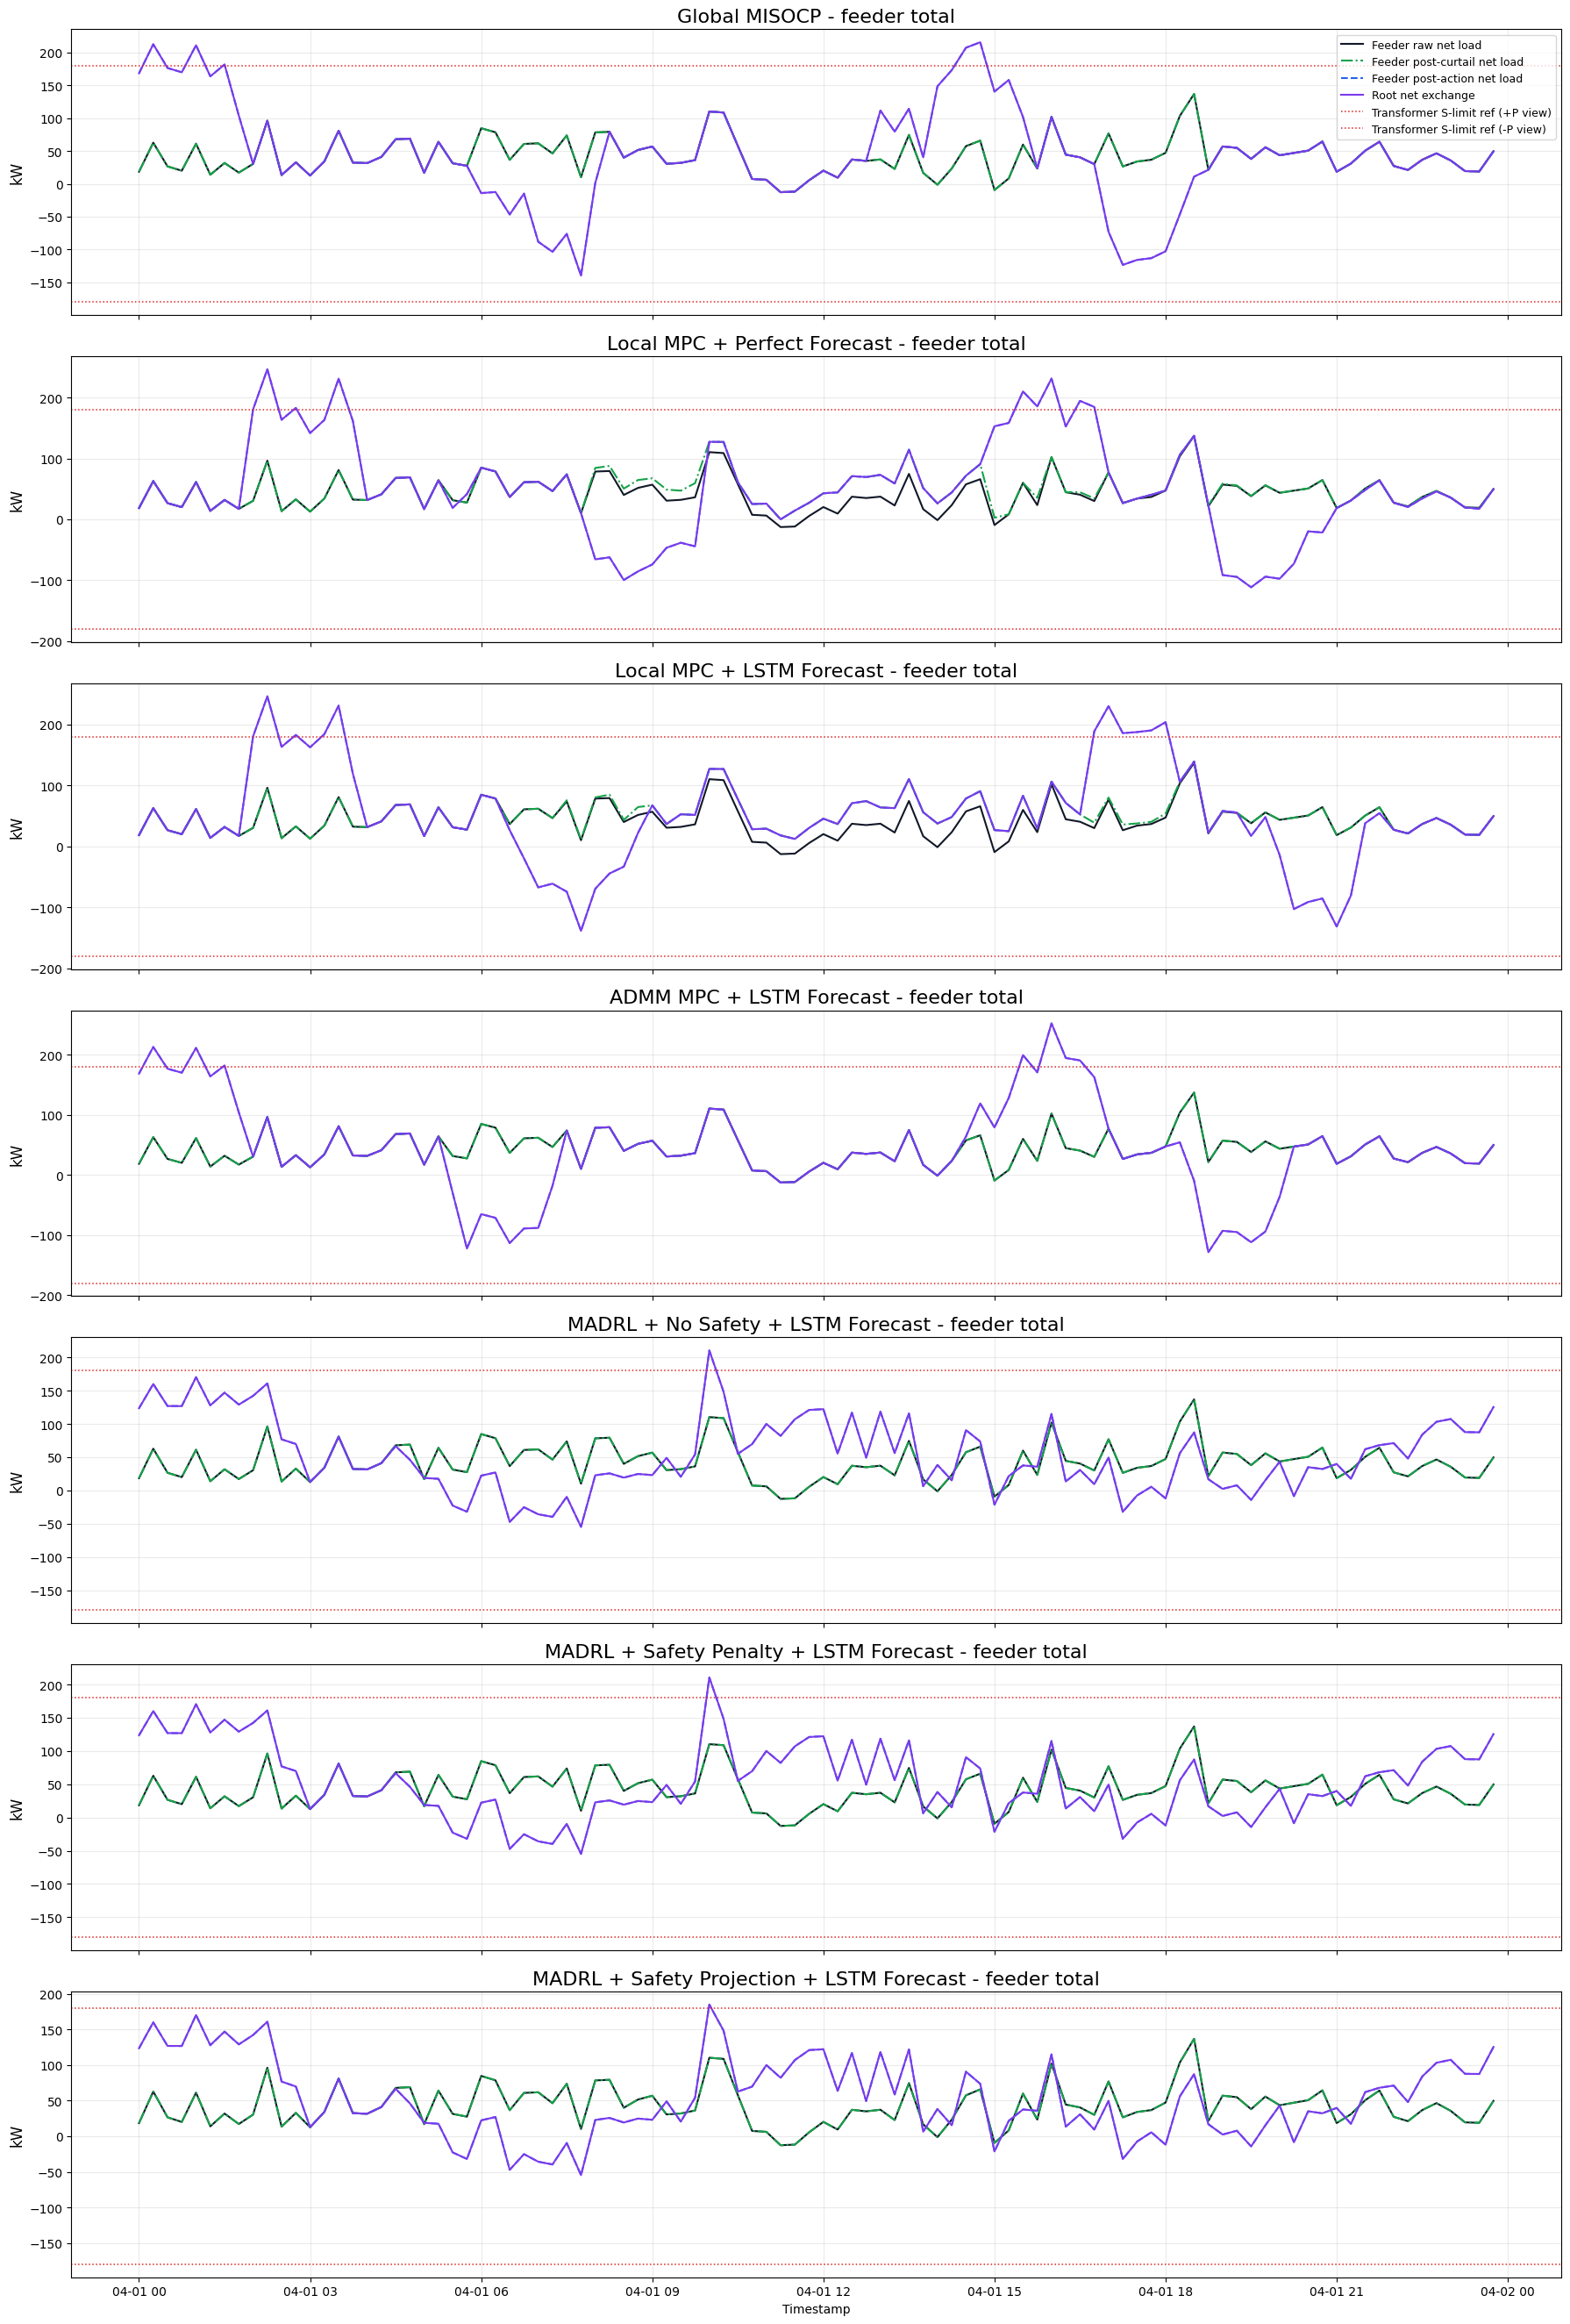

4. 总体储能充放功率与 SoC


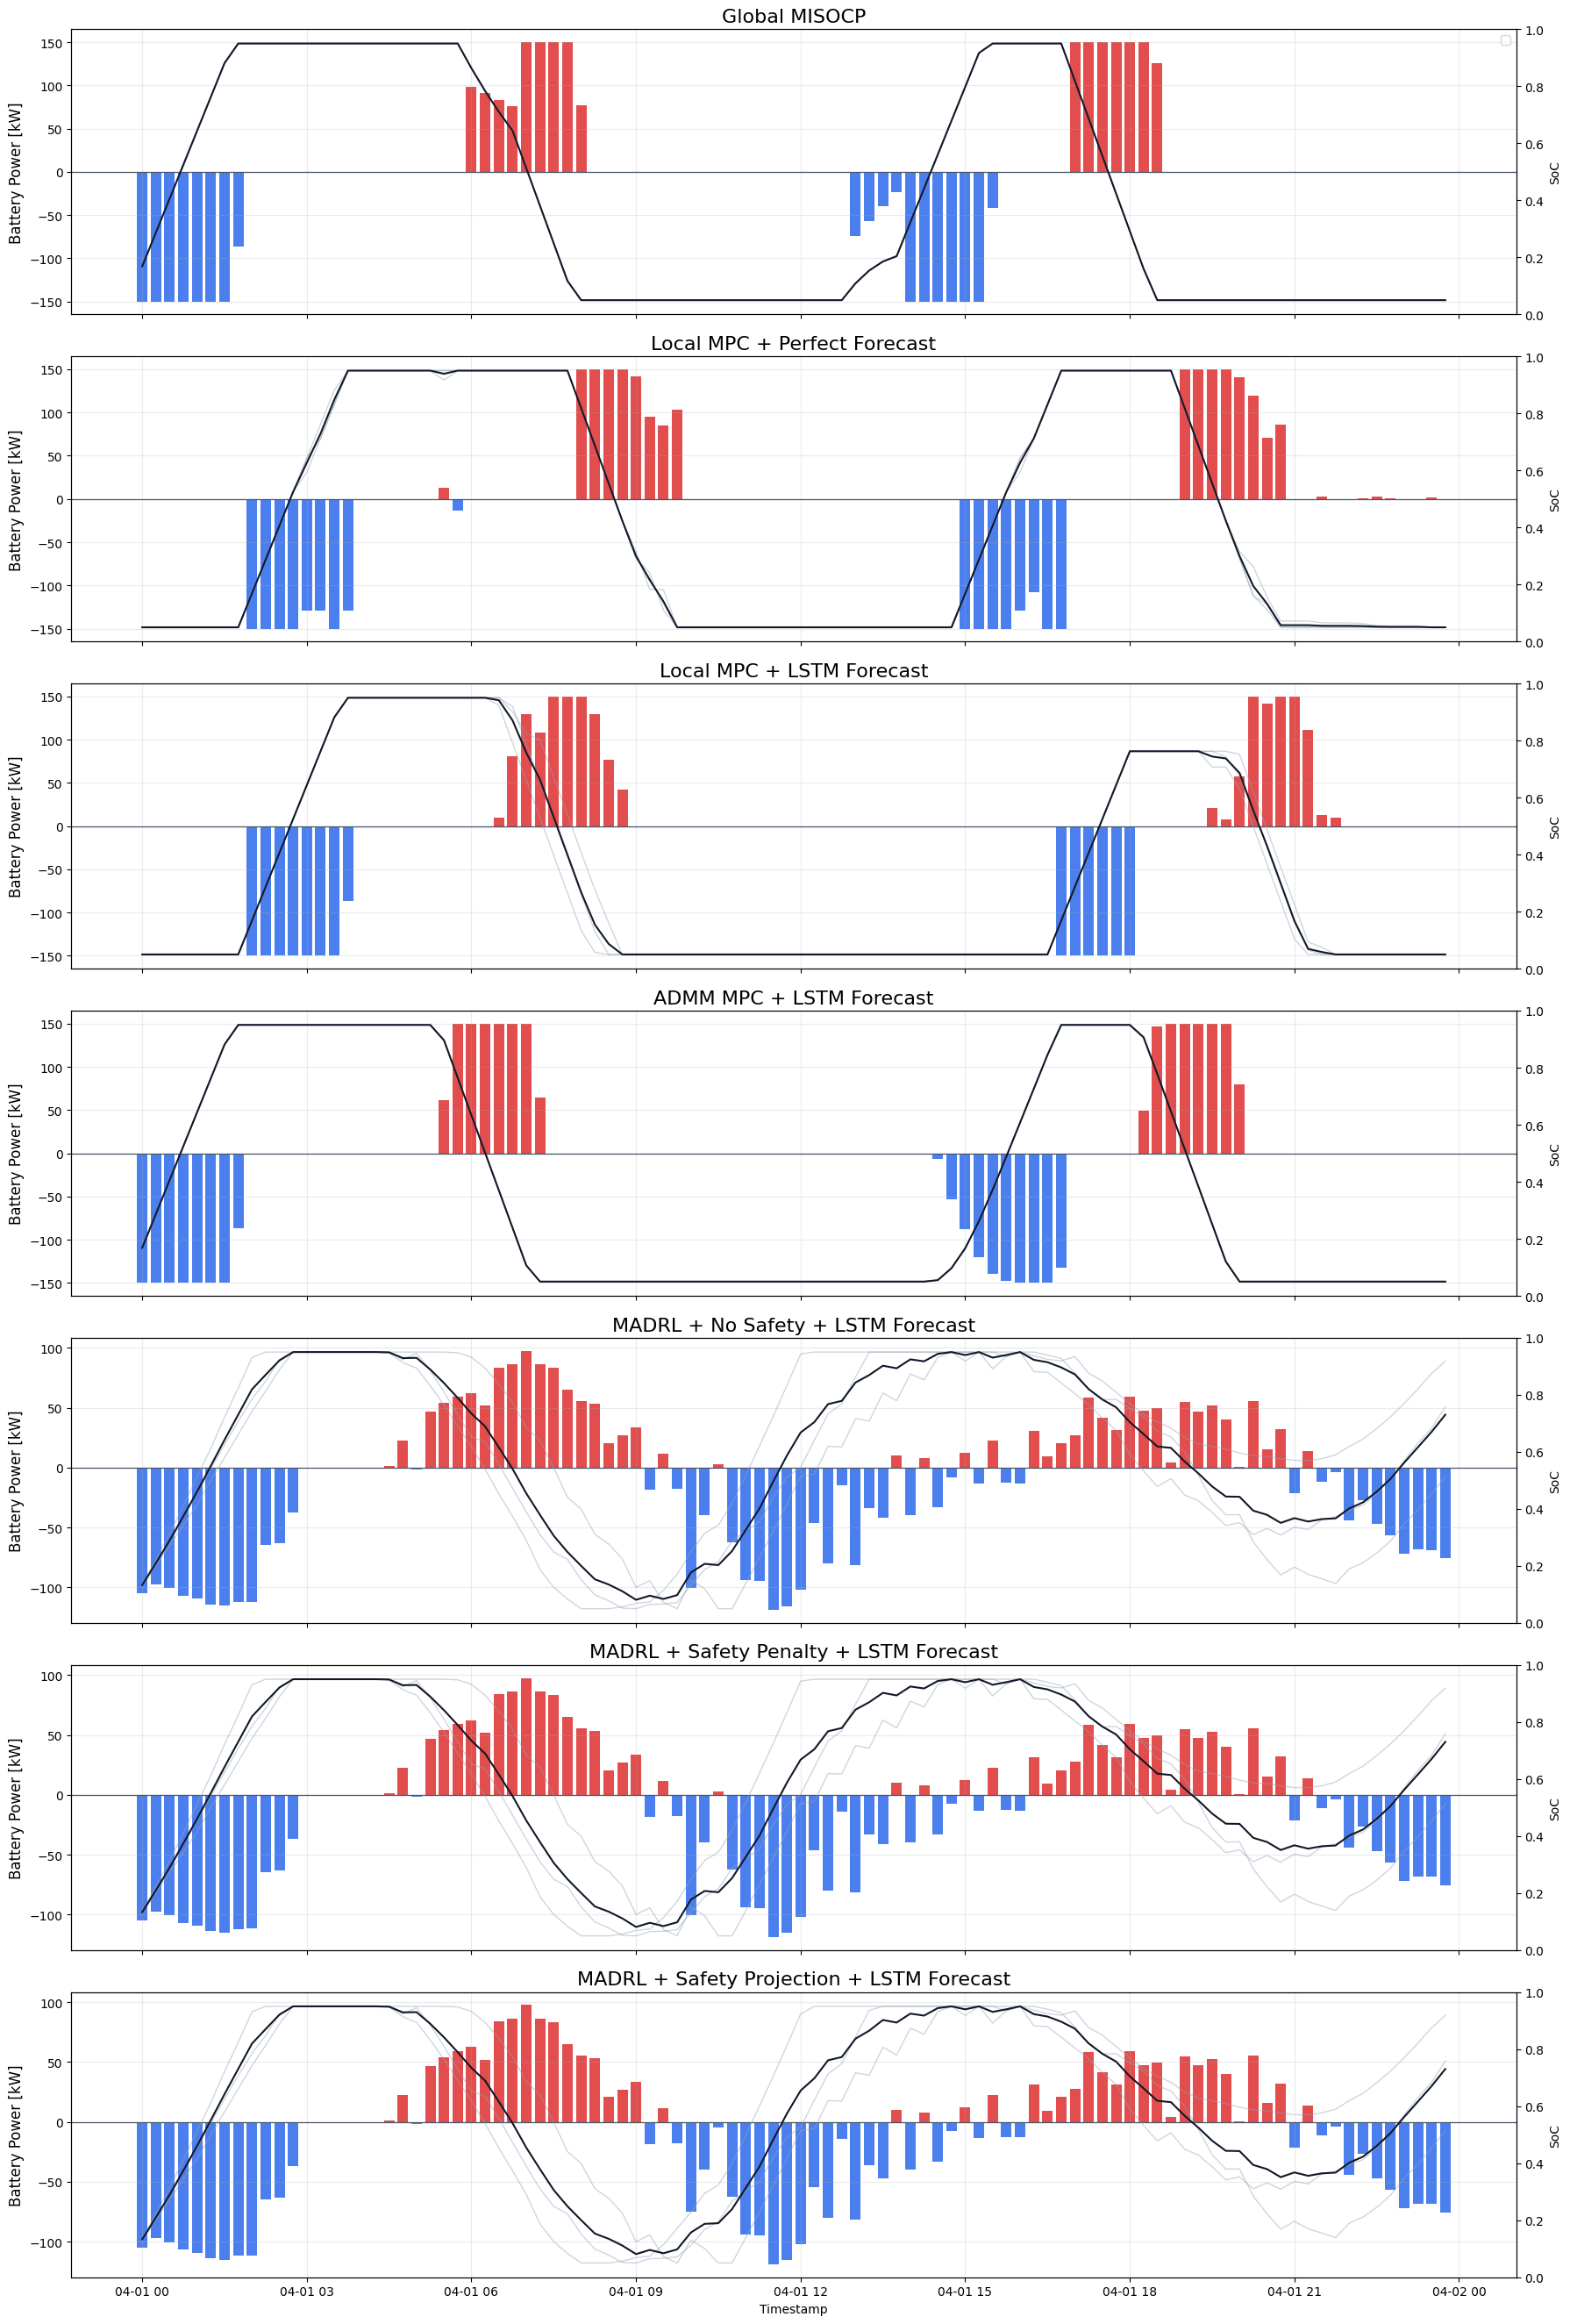

5. 电力电量平衡


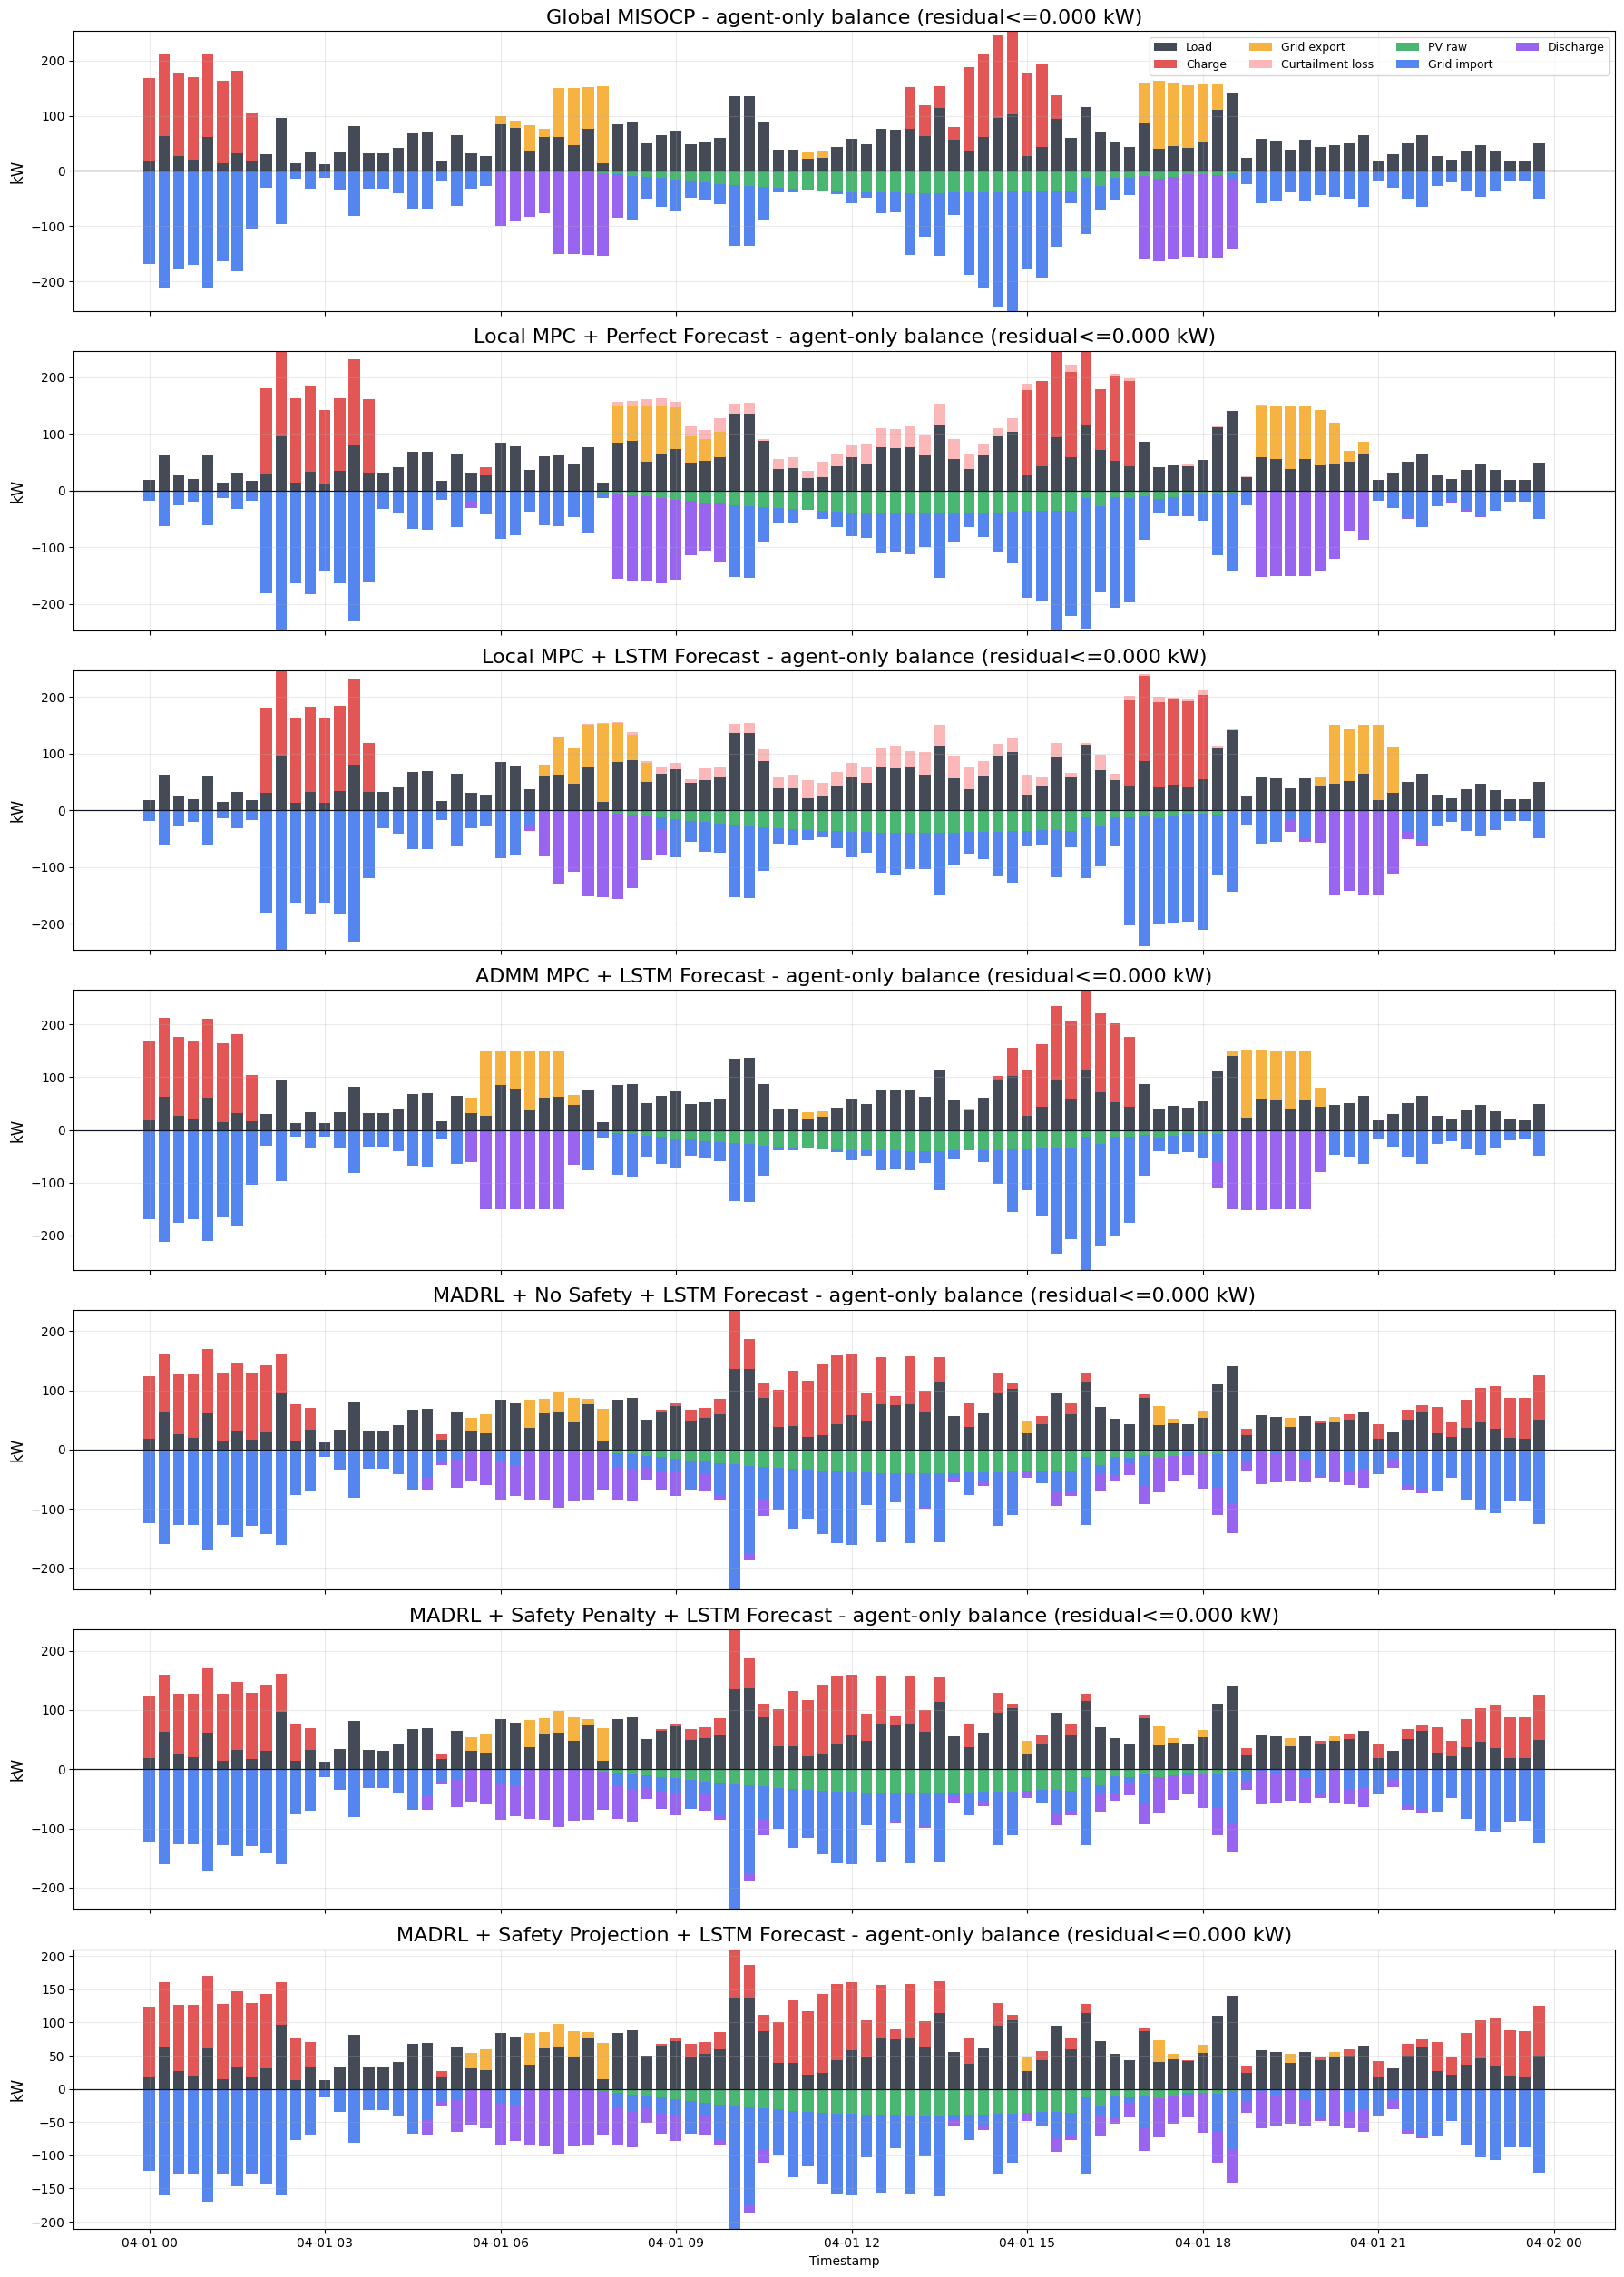

In [1]:
from pathlib import Path
import os
import sys

_here = Path.cwd().resolve()
_repo_root = next(path for path in (_here, *_here.parents) if (path / "REMAKE" / "configs" / "cfg.py").exists())
os.chdir(_repo_root)
sys.path.insert(0, str(_repo_root))

import matplotlib.pyplot as plt
from IPython.display import display

from REMAKE.scripts.compare import compare_records
from REMAKE.utils.run_artifacts import load_experiment_context

cfg, run_dir = load_experiment_context('artifacts/runs/20260504_193738_6ac06409')
result = compare_records(cfg, run_dir)
display(result["metrics_df"])
display(result["economic_table"])
display(result["safety_table"])

_plot_specs = [
    ("1. 电价", "compare_price"),
    ("2. 电压", "compare_voltage"),
    ("3. 净负荷", "compare_net_load"),
    ("4. 总体储能充放功率与 SoC", "compare_battery_soc"),
    ("5. 电力电量平衡", "compare_power_balance"),
]
for title, name in _plot_specs:
    print(title)
    display(result["figures"][name])
    plt.close(result["figures"][name])
